# 10 - Robustness: trying to kill the signal

Every variant is run on the test period **after** the frozen result is recorded. The variants are reported, never used to change the selection. They cover:
- thresholds and position modes;
- removing each feature group;
- swapping the model;
- execution lag of 0 or 5 min;
- decision times offset to :15, :30 and :45;
- horizons of 15 and 30 min;
- a label-permutation test.

The full experiment count, including failures, is in `reports/tables/experiment_log.csv` and feeds the Deflated Sharpe Ratio.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
import run_pipeline as rp
from src import config
T, F = config.TABLES_DIR, config.FIGURES_DIR
SYMBOL = config.SYMBOL
# False (default): display the outputs saved by scripts/run_pipeline.py.
# True re-computes the stage. Do NOT re-run 'validation' or 'test' casually:
# validation resets the experiment log and every test run adds a TEST row.
RUN_STAGE = False
def show(name, **kw):
    display(Markdown(f"**{name}**")); display(pd.read_csv(T / name, **kw))
def fig(name):
    display(Image(filename=str(F / name)))
def results(section):
    return json.loads((config.REPORTS_DIR / "results.json").read_text()).get(section, {})

In [2]:
if RUN_STAGE:
    rp.stage_robustness(SYMBOL)

In [3]:
show('robustness_variants.csv')

**robustness_variants.csv**

,variant,auc,ic,net_sharpe,gross_sharpe,annualized_return,max_drawdown,exposure,trades_per_year
0,"threshold k=0.0, long_short",0.544752,0.065047,-8.823435,2.052729,-0.986549,-0.999993,1.000000,3685.394480
1,"threshold k=0.0, long_flat",0.544752,0.065047,-5.277073,1.831296,-0.862500,-0.995856,0.556755,3685.394480
2,"threshold k=0.25, long_short",0.544752,0.065047,-9.585322,1.797633,-0.987101,-0.999994,0.853746,4705.153683
3,"threshold k=0.25, long_flat",0.544752,0.065047,-6.010777,1.625671,-0.879612,-0.997173,0.482092,3731.234530
4,"threshold k=0.5, long_short",0.544752,0.065047,-10.144216,1.489676,-0.985237,-0.999991,0.705748,5230.495206
5,"threshold k=0.5, long_flat",0.544752,0.065047,-6.605698,1.385370,-0.884523,-0.997470,0.408965,3638.826811
6,"threshold k=1.0, long_short",0.544752,0.065047,-10.062828,0.938921,-0.963498,-0.999890,0.425814,4708.427973
7,"threshold k=1.0, long_flat",0.544752,0.065047,-6.951035,0.908449,-0.839584,-0.993713,0.252750,2899.565055
8,"threshold k=1.5, long_short",0.544752,0.065047,-8.247280,0.204318,-0.811147,-0.989802,0.164100,2386.956879
9,"threshold k=1.5, long_flat",0.544752,0.065047,-5.805727,0.164526,-0.601885,-0.921810,0.091222,1334.454783


In [4]:
show('experiment_log.csv')

**experiment_log.csv**

,logged_utc,stage,model,params,n_features,features,horizon_min,lag_min,offset_min,train_period,eval_period,metric_model,n,base_rate,mean_p,auc,logloss,brier,accuracy,precision,recall,f1,share_predicted_up,ic_spearman,mean_fold_auc,...,test_cost_sum,test_funding_sum,test_net_sum,test_gross_sharpe,test_exposure,test_n_position_changes,test_turnover_per_year,test_trades_per_year,test_round_trips_per_year,test_win_rate,test_avg_win,test_avg_loss,test_profit_factor,test_sharpe_ci_low,test_sharpe_ci_high,test_psr_vs_0,dsr,variant,ic,net_sharpe,gross_sharpe,annualized_return,max_drawdown,exposure,trades_per_year
0,2026-10-05T21:23:07+00:00,validation-model,base_rate,{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,base_rate,43415.0,0.507590,0.509682,0.496401,0.693082,0.249968,0.507590,0.507590,1.000000,0.673379,1.000000,-0.002058,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-10-05T21:23:07+00:00,validation-model,logreg|C=0.01,{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,logreg|C=0.01,43415.0,0.507590,0.510145,0.556993,0.688283,0.247573,0.543867,0.545960,0.602124,0.572668,0.559807,0.080546,0.559772,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-10-05T21:23:08+00:00,validation-model,logreg|C=0.1,{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,logreg|C=0.1,43415.0,0.507590,0.510118,0.556970,0.688298,0.247580,0.543453,0.545683,0.600581,0.571817,0.558655,0.080527,0.559614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-10-05T21:23:08+00:00,validation-model,logreg|C=1.0,{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,logreg|C=1.0,43415.0,0.507590,0.510121,0.556962,0.688302,0.247581,0.543338,0.545574,0.600535,0.571737,0.558724,0.080511,0.559596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-10-05T21:23:08+00:00,validation-model,"lgbm|colsample_bytree=0.8,learning_rate=0.03,m...",{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,"lgbm|colsample_bytree=0.8,learning_rate=0.03,m...",43415.0,0.507590,0.509778,0.564914,0.687199,0.247024,0.549119,0.551675,0.596361,0.573148,0.548704,0.086943,0.566154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-10-05T21:23:09+00:00,validation-model,"lgbm|colsample_bytree=0.8,learning_rate=0.02,m...",{},16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,expanding from 2017-08-17,2019-01-01..2023-12-31,"lgbm|colsample_bytree=0.8,learning_rate=0.02,m...",43415.0,0.507590,0.509795,0.562503,0.688564,0.247676,0.548497,0.550905,0.597904,0.573443,0.550893,0.082253,0.563469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-10-05T21:23:09+00:00,validation-signal,"lgbm|colsample_bytree=0.8,learning_rate=0.03,m...","{""k"": 0.0, ""mode"": ""long_short""}",16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,walk-forward,development validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-10-05T21:23:09+00:00,validation-signal,"lgbm|colsample_bytree=0.8,learning_rate=0.03,m...","{""k"": 0.0, ""mode"": ""long_flat""}",16,"ret_1m,ret_5m,ret_15m,ret_30m,ret_60m,ret_4h,r...",60,1,0,walk-forward,development validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-10-0

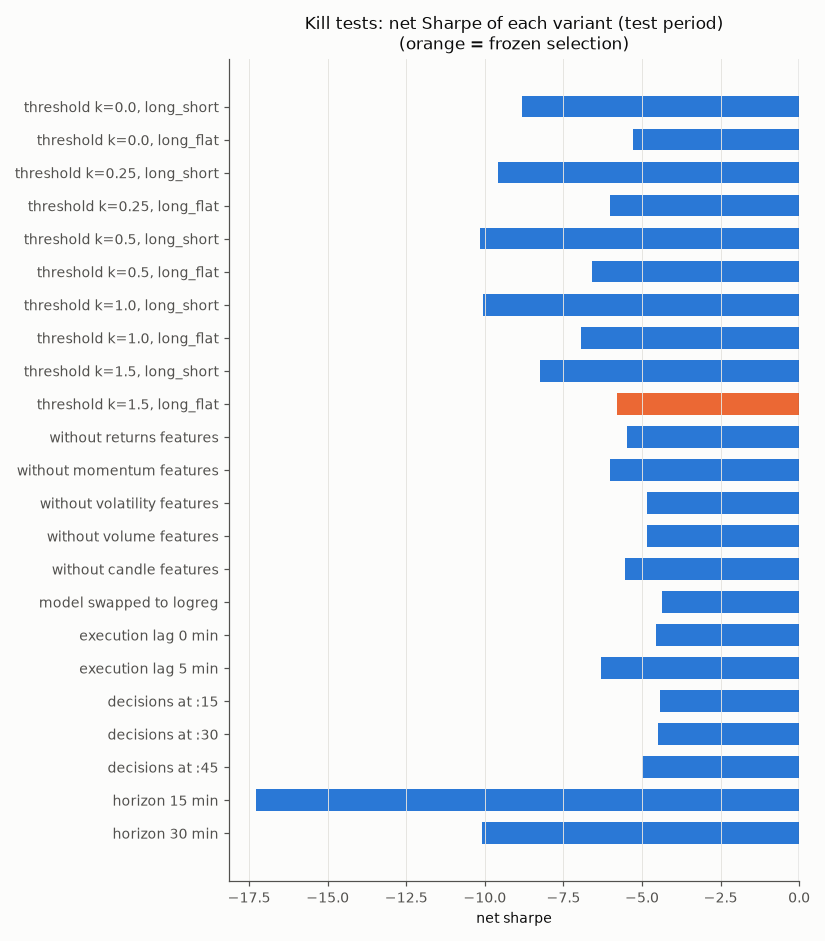

In [5]:
fig('robustness_variants.png')

In [6]:
results('robustness').get('permutation')

{'real_auc': 0.5404168238550058,
 'null_mean': 0.500697034110128,
 'null_p95': 0.523424922198232,
 'p_value': 0.004975124378109453,
 'n_perm': 200}

**Interpretation:** see the matching section of `reports/final_report.md`, written from these outputs.